# 3. Frozen hold-out test and model comparison

This notebook compares the frozen TCN, local CNN, BiGRU, U-Net, and classical detector
on the same synthetic hold-out fold. Run both `02_tcn_training_and_evaluation.ipynb`
and `02_unet_training_and_evaluation.ipynb` first to export their checkpoints,
train-fitted preprocessing, and validation-selected thresholds. No model,
hyperparameter, epoch, post-processing rule, or threshold is changed in response
to the results below. This separation keeps the hold-out metrics interpretable as
a final estimate rather than another model-selection signal.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from deeplearning_examples.io import load_data
from burst_detection.artifacts import load_holdout_manifest, preprocessor_from_checkpoint
from burst_detection.classical import detect_classical_bursts
from burst_detection.data import fit_archetype_bank, generate_dataset_splits
from burst_detection.metrics import evaluate_burst_predictions
from burst_detection.training import artifact_root, load_checkpoint, predict_probabilities
from burst_detection.visualization import plot_probability_comparison

## Reconstruct the frozen test protocol

Load `holdout_models.json` for TCN/CNN/BiGRU and `unet_holdout_models.json` for U-Net.
Their split definitions and selection protocols must match before combining the
candidates; duplicate architecture names are rejected to prevent silent replacement.
Both manifest files are required, so missing U-Net training artifacts cannot silently
remove the U-Net from the comparison.

Experimental training trajectories reconstruct the background-archetype bank.
Every neural checkpoint supplies its own train-fitted preprocessing statistics,
preventing normalization leakage from validation or test. The hold-out fold is
reconstructed once and shared by all four neural models and the classical detector.

In [2]:
manifest_paths = [
    artifact_root() / "holdout_models.json",
    artifact_root() / "unet_holdout_models.json",
]
manifests = []
for path in manifest_paths:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing frozen manifest: {path}. Run both 02_ training notebooks first."
        )
    manifests.append(load_holdout_manifest(path))

manifest = dict(manifests[0])
manifest["candidates"] = []
seen_architectures = set()
for path, candidate_manifest in zip(manifest_paths, manifests):
    for key in ("split_config", "selection_fold", "threshold_metric"):
        if candidate_manifest[key] != manifest[key]:
            raise ValueError(f"Incompatible {key} in {path.name}; use the same frozen protocol.")
    for candidate in candidate_manifest["candidates"]:
        architecture = candidate["architecture"]
        if architecture in seen_architectures:
            raise ValueError(f"Duplicate architecture in frozen manifests: {architecture}.")
        seen_architectures.add(architecture)
        manifest["candidates"].append(candidate)

split_config = dict(manifest["split_config"])
archetype_seed = split_config.pop("archetype_seed")
experimental_train, doses, _ = load_data("train")
archetypes = fit_archetype_bank(
    experimental_train[doses == "100pM"], random_seed=archetype_seed,
)
holdout = generate_dataset_splits(archetypes=archetypes, **split_config).test
len(holdout.signals), holdout.signals.shape, manifest["selection_fold"]

(200, (200, 289), 'validation')

## Frozen neural inference

Each checkpoint is reconstructed from its serialized model name and architecture configuration. Probabilities are generated in evaluation mode and paired with the threshold stored before the hold-out fold was opened. A mismatch between checkpoint and manifest metadata raises an error instead of silently evaluating a different model.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = {}
probabilities = {}
thresholds = {}

for candidate in manifest["candidates"]:
    architecture = candidate["architecture"]
    checkpoint_path = artifact_root() / candidate["checkpoint"]
    model, checkpoint = load_checkpoint(checkpoint_path, device=device)
    if checkpoint["model_name"] != candidate["model_name"]:
        raise ValueError(f"Model metadata mismatch for {architecture}.")
    preprocessor = preprocessor_from_checkpoint(checkpoint)
    holdout_x = preprocessor.transform(holdout.signals)
    models[architecture] = model
    probabilities[architecture] = predict_probabilities(
        model, holdout_x, device=device,
    )
    thresholds[architecture] = float(candidate["threshold"])

pd.DataFrame({
    candidate["architecture"]: {
        "checkpoint": candidate["checkpoint"],
        "threshold": candidate["threshold"],
        "parameters": candidate.get("parameter_count"),
        "validation_best_epoch": candidate.get("best_epoch"),
    }
    for candidate in manifest["candidates"]
}).T

,checkpoint,threshold,parameters,validation_best_epoch
tcn,best_tcn.pt,0.7,140161,13
cnn,best_cnn.pt,0.6,208513,29
bigru,best_bigru.pt,0.8,57121,42
unet,best_unet.pt,0.6,367969,34


## Hold-out metrics

Pointwise metrics score individual time points. Event metrics first convert each probability sequence into intervals and then match predicted and true events one-to-one by intersection-over-union. Average precision and ROC AUC use continuous probabilities and do not depend on the frozen threshold. Event F1, count error, center-time error, and duration error characterize the biologically more relevant interval reconstruction. The classical detector is included as a fixed, non-probabilistic reference.

In [4]:
metric_rows = {
    architecture: evaluate_burst_predictions(
        holdout.labels, scores, threshold=thresholds[architecture],
    ).to_dict()
    for architecture, scores in probabilities.items()
}
classical_mask = detect_classical_bursts(holdout.signals)
metric_rows["classical"] = evaluate_burst_predictions(
    holdout.labels, classical_mask.astype(float), threshold=0.5,
).to_dict()
holdout_results = pd.DataFrame(metric_rows).T
display(holdout_results.round(4))

,point_precision,point_recall,point_f1,average_precision,roc_auc,event_precision,event_recall,event_f1,true_event_count,predicted_event_count,matched_event_count,burst_count_mae,center_time_mae_minutes,duration_mae_minutes
tcn,0.9599,0.8916,0.9245,0.9850,0.9865,0.9593,0.9721,0.9656,896.0,908.0,871.0,0.260,4.6240,13.1745
cnn,0.9385,0.9152,0.9267,0.9836,0.9850,0.9530,0.9721,0.9624,896.0,914.0,871.0,0.280,4.3599,11.1883
bigru,0.9685,0.8735,0.9185,0.9838,0.9852,0.9752,0.9654,0.9703,896.0,887.0,865.0,0.235,4.4480,13.7168
unet,0.9420,0.9193,0.9305,0.9851,0.9863,0.9636,0.9743,0.9689,896.0,906.0,873.0,0.250,4.3156,10.6014
classical,0.7636,0.8591,0.8086,0.7187,0.8232,0.9433,0.9096,0.9261,896.0,864.0,815.0,0.560,15.6380,41.7914


## Direct performance comparison

The panels separate scores, for which larger values are better, from localization and counting errors, for which smaller values are better. Keeping the error units explicit avoids combining incomparable quantities into a single aggregate score. The classical AP and ROC AUC reflect binary decisions rather than calibrated rankings and are therefore only weak reference values.

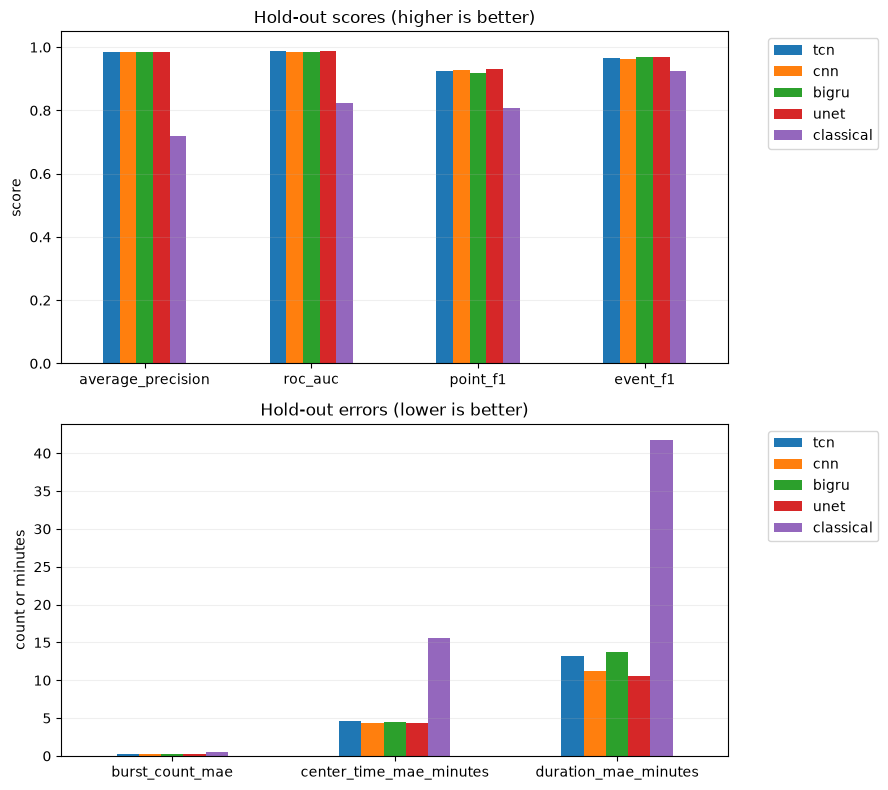

In [8]:
score_metrics = ["average_precision", "roc_auc", "point_f1", "event_f1"]
error_metrics = ["burst_count_mae", "center_time_mae_minutes", "duration_mae_minutes"]

figure, axes = plt.subplots(2, 1, figsize=(9, 8))
holdout_results[score_metrics].T.plot.bar(ax=axes[0], rot=0)
axes[0].set(title="Hold-out scores (higher is better)", ylabel="score", ylim=(0, 1.05))
axes[0].legend(ncol=1, bbox_to_anchor=(1.05, 1)); axes[0].grid(axis="y", alpha=0.2)
holdout_results[error_metrics].T.plot.bar(ax=axes[1], rot=0)
axes[1].set(title="Hold-out errors (lower is better)", ylabel="count or minutes")
axes[1].legend(ncol=1, bbox_to_anchor=(1.05, 1)); axes[1].grid(axis="y", alpha=0.2)

figure.tight_layout()

### Interpretation

A convincing neural candidate should combine high average precision with high pointwise and event F1 rather than winning only one metric. Count and timing errors distinguish models that obtain similar overlap scores but fragment events or displace their centers. Differences observed here describe generalization of already frozen candidates; they must not be used to retune the same pipeline against this hold-out fold.

## Probability and event examples

The same hold-out trajectories appear in every architecture column. Blue curves are burst probabilities, dotted horizontal lines are the frozen validation thresholds, green regions are true events, and red regions are thresholded predictions. These examples reveal boundary shifts, missed short events, and false splitting that summary metrics can conceal.

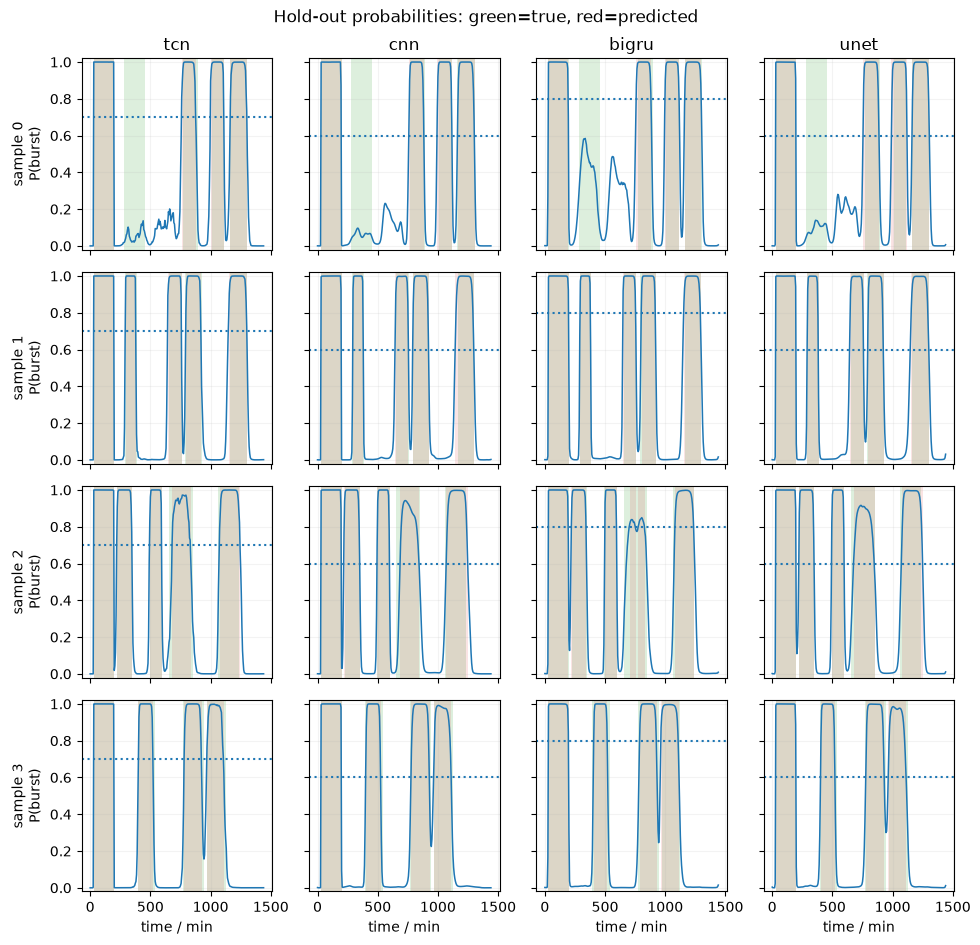

In [9]:
plot_probability_comparison(
    holdout.signals, holdout.labels, probabilities, thresholds,
    time_minutes=holdout.time_minutes, maximum_examples=4,
);

### Interpretation

Agreement across architectures on event location is stronger evidence than a single sharply peaked probability trace. Systematic boundary expansion suggests threshold or class-weight calibration effects, whereas isolated narrow peaks indicate fragmentation. The examples are diagnostic illustrations and do not replace the aggregate evaluation over all 200 hold-out trajectories.

## Conclusion

This notebook completes the frozen synthetic benchmark by comparing the selected TCN, local CNN, BiGRU, U-Net, and classical detector on exactly one untouched split. The most credible model is the one whose hold-out ranking is supported jointly by probability ranking, event recovery, and localization error. Any subsequent architectural or threshold changes define a new development cycle and require a new independent test set. The results remain evidence for synthetic bursts on experimentally derived backgrounds, not yet for manually annotated biological events.